# Patryk Kozuch - lab 6

In [32]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Download the dataset

In [2]:
from datasets import load_dataset

dataset = load_dataset('PolyAI/banking77', trust_remote_code=True)

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

### Explore the dataset

In [7]:
import pandas as pd

df_train = dataset['train'].to_pandas()
df_test = dataset['test'].to_pandas()

df_full = pd.concat([df_train, df_test], ignore_index=True)

In [10]:
df_full

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11
...,...,...
13078,"If i'm not in the UK, can I still get a card?",24
13079,How many countries do you support?,24
13080,What countries do you do business in?,24
13081,What are the countries you operate in.,24


In [9]:
df_full.dtypes

text     object
label     int64
dtype: object

In [12]:
print("None count in 'text' column:", df_full['text'].isna().sum())
print("None count in 'label' column:", df_full['label'].isna().sum())

None count in 'text' column: 0
None count in 'label' column: 0


In [14]:
df_full['text'].value_counts().head(10)

text
I am still waiting on my card?                                                                                                                         1
My transfer is pending too long.                                                                                                                       1
Why is  my balance not updated?                                                                                                                        1
I'm wondering how long it takes for my money to get to me after a bank transfer.                                                                       1
Hi. About two hours ago I made a transfer from my bank which is in the UK, but I don't see it yet! Would you check what's going on with it, please?    1
When does a UK transfer show up?                                                                                                                       1
I do not see the money I transferred into this account                       

There are no empty or missing values in the dataset.

<Axes: >

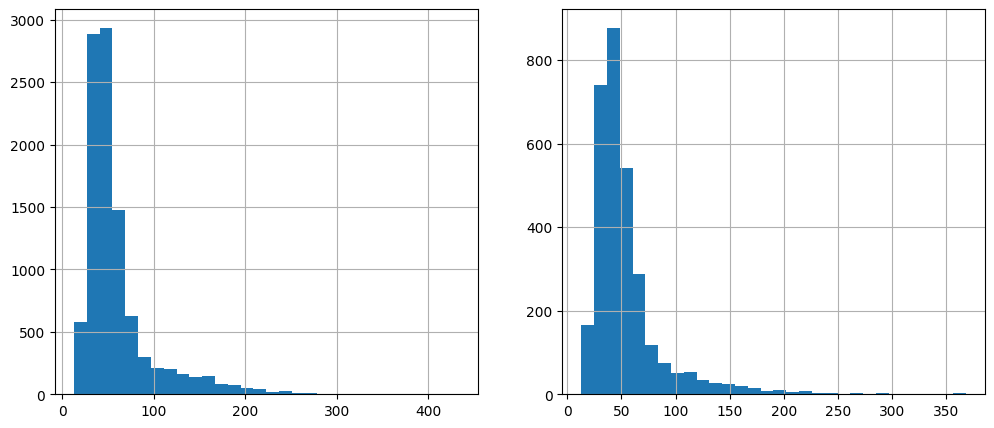

In [17]:
from matplotlib import pyplot as plt

f, ax = plt.subplots(1, 2, figsize=(12, 5))

df_train['text'].str.len().hist(ax=ax[0], bins=30)
df_test['text'].str.len().hist(ax=ax[1], bins=30)

Distribution of text length in training and test sets looks similar.

<Axes: title={'center': 'Test dataset'}>

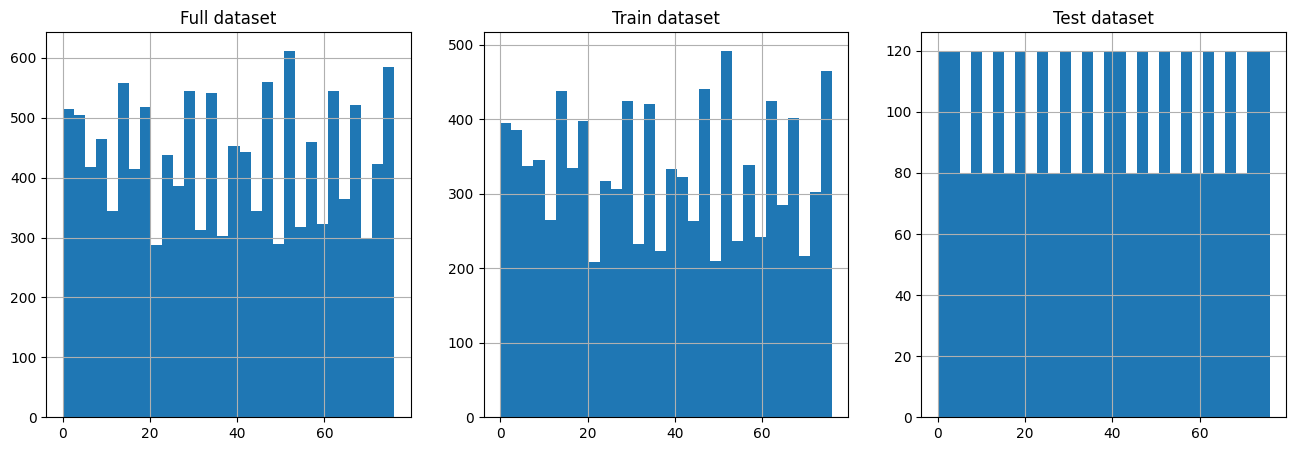

In [28]:
from matplotlib import pyplot as plt

f, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].set_title('Full dataset')
df_full['label'].hist(ax=ax[0], bins=30)
ax[1].set_title('Train dataset')
df_train['label'].hist(ax=ax[1], bins=30)
ax[2].set_title('Test dataset')
df_test['label'].hist(ax=ax[2], bins=30)

However, the distribution of labels is different in training and test sets - test set is more (but not completely) balanced. In training data there is a visible dominance of some labels over others.

## Cleanup labels

In [48]:
import joblib
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict


def get_initial_model_data(texts: np.ndarray, labels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)
    clf = LogisticRegression(max_iter=1000, random_state=0, class_weight="balanced")
    pred_probs = cross_val_predict(
        clf,
        embeddings,
        labels,
        cv=5,
        method="predict_proba",
        n_jobs=joblib.cpu_count(only_physical_cores=True),
    )

    return embeddings, pred_probs

### Examine train data

In [49]:
texts = df_train["text"].values
labels = df_train["label"].values

embeddings, pred_probs = get_initial_model_data(texts, labels)

RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [39]:
from cleanlab import Datalab


data_dict = {"texts": texts, "labels": labels}
lab = Datalab(data_dict, label_name="labels", task="classification")
lab.find_issues(pred_probs=pred_probs, features=embeddings)
lab.report()

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 648 issues found in the dataset.
Dataset Information: num_examples: 10003, num_classes: 77

Here is a summary of various issues found in your data:

    issue_type  num_issues
near_duplicate         350
         label         166
       outlier         131
       non_iid           1

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


------------------ near_duplicate issues -------------------

About this issue:
	A (near) duplicate issue refers to two or more examples in
    a dataset that are extremely similar to each other, relative
  

In [44]:
duplicate_issues = lab.get_issues("near_duplicate")
duplicate_issues = duplicate_issues[duplicate_issues["is_near_duplicate_issue"]]
duplicate_issues = duplicate_issues.sort_values(by="near_duplicate_score")

In [46]:
for idx, row in duplicate_issues.head(10).iterrows():
    text = texts[idx]
    neighbors = texts[row["near_duplicate_sets"][:3]]
    print(f"Text: {text}")
    print(f"\tDuplicates: {neighbors}")
    print()

Text: Which ATMs accept this card?
	Duplicates: ['\nWhich ATMs accept this card?']

Text: 
Which ATMs accept this card?
	Duplicates: ['Which ATMs accept this card?']

Text: How do I link a card that I already have?
	Duplicates: ['how do I link a card I already have?']

Text: how do I link a card I already have?
	Duplicates: ['How do I link a card that I already have?']

Text: How long to I have to wait for a transfer to reach my account?
	Duplicates: ['How long do i have to wait for a transfer to reach my account?']

Text: How long do i have to wait for a transfer to reach my account?
	Duplicates: ['How long to I have to wait for a transfer to reach my account?']

Text: Is there a limit for top-ups?
	Duplicates: ['Is there a limit to top-ups?' 'Is there a limit on top-ups?']

Text: Is there a limit to top-ups?
	Duplicates: ['Is there a limit for top-ups?']

Text: Are there any fees for top ups?
	Duplicates: ['Are there fees for top ups?']

Text: Are there fees for top ups?
	Duplicates:

In [40]:
texts = df_test["text"].values
labels = df_test["label"].values

embeddings, pred_probs = get_initial_model_data(texts, labels)

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

In [41]:
from cleanlab import Datalab


data_dict = {"texts": texts, "labels": labels}
lab = Datalab(data_dict, label_name="labels", task="classification")
lab.find_issues(pred_probs=pred_probs, features=embeddings)
lab.report()

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 179 issues found in the dataset.
Dataset Information: num_examples: 3080, num_classes: 77

Here is a summary of various issues found in your data:

    issue_type  num_issues
         label          73
near_duplicate          73
       outlier          32
       non_iid           1

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


----------------------- label issues -----------------------

About this issue:
	Examples whose given label is estimated to be potentially incorrect
    (e.g. due to annotation error) are flagged as having la